# Notebook 05 — Time

## Overview

Every event happens *at a time*. A pizza order arrives, baking begins, baking ends, and the pizza is delivered — each of these happenings occupies a position on the timeline. Ontologies that represent processes (as we did in notebook 03) are incomplete without some account of *when* those processes occur.

SULO provides a minimal but sufficient vocabulary for temporal representation:

| Class | Description |
|---|---|
| `sulo:TimeInstant` | A specific point on the timeline |
| `sulo:StartTime` | A `TimeInstant` marking the beginning of something |
| `sulo:EndTime` | A `TimeInstant` marking the end of something |
| `sulo:Duration` | A measured amount of elapsed time |

The object property `sulo:atTime` links any entity to a `Time` individual, while `sulo:precedes` (introduced in notebook 03) provides relative ordering between time instants and processes.

Beyond recording *when* things happen, `atTime` also enables **classification of processes**: a delivery process that is linked to a `DeliveryDuration` with `hasValue ≤ 30` can be automatically classified as `ExpressPizzaDelivery` by the reasoner.

## Learning Objectives

1. Understand SULO's time class hierarchy (`TimeInstant`, `StartTime`, `EndTime`, `Duration`) and the `atTime` property
2. Define named time-instant subclasses using `isTimeOf` restrictions tied to specific process classes
3. Constrain `Duration` subclasses using `hasValue` with `ConstrainedDatatype`, parallel to the quantity pattern from notebook 02
4. Attach time instants to process classes at the TBox level using `atTime some`
5. Build an instance-level temporal chain linking time instants with `precedes` and verify transitivity via `INDIRECT_temporallyPrecedes`
6. Define a process subclass using a combined `atTime` and `ConstrainedDatatype` restriction, and verify that individual processes are classified automatically by the reasoner

## Getting started

The following cell loads SULO, the `pro` ontology, and the pizza ontology built in notebook 04.

In [154]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
pro = get_ontology("dist/pro.owl").load()
pizza = get_ontology("dist/pizza-04.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(pro)


result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

print("Loaded pizza ontology. Classes:", len(list(pizza.classes())))

Consistent: True
Loaded pizza ontology. Classes: 64


## Time Instant Subclasses

We define four concrete time-instant types specific to the pizza lifecycle:

| Class | Parent | Meaning |
|---|---|---|
| `OrderReceivedTime` | `sulo:StartTime` | The moment a pizza order arrives |
| `BakingStartTime` | `sulo:StartTime` | The moment baking begins |
| `BakingEndTime` | `sulo:EndTime` | The moment baking ends |
| `DeliveryTime` | `sulo:TimeInstant` | The moment the pizza is delivered |

Each is defined as a `equivalent_to` restriction using `sulo:isTimeOf` (the inverse of `atTime`) to tie the instant to the process it marks. This means the reasoner can automatically classify any `StartTime` individual that is the time of a `BakingThePizza` instance as a `BakingStartTime`.

In [155]:
with pizza:
    class OrderingProcess(pro.TransformationProcess):
        """The process of placing a pizza order — the first step in the pizza lifecycle,
        preceding all production processes."""
        label = [locstr("ordering process", "en")]

    class DeliveringThePizza(pro.TransformationProcess):
        """The process of delivering the finished pizza to the customer."""
        label = [locstr("delivering the pizza", "en")]

# Chain: OrderingProcess precedes MakingThePizzaDough
OrderingProcess.is_a.append(sulo.precedes.some(pizza.MakingThePizzaDough))
# Chain: SlicingThePizza precedes DeliveringThePizza
pizza.SlicingThePizza.is_a.append(sulo.precedes.some(DeliveringThePizza))

print("OrderingProcess is_a:", OrderingProcess.is_a)
print("SlicingThePizza precedes:", [a for a in pizza.SlicingThePizza.is_a if hasattr(a, 'property') and a.property == sulo.precedes])

OrderingProcess is_a: [pro.TransformationProcess, sulo.precedes.some(pizza-02.MakingThePizzaDough), sulo.precedes.some(pizza-02.MakingThePizzaDough)]
SlicingThePizza precedes: [sulo.precedes.some(pizza-04.DeliveringThePizza), sulo.precedes.some(pizza-04.DeliveringThePizza)]


In [156]:
with pizza:
    class OrderReceivedTime(sulo.StartTime):
        """The point in time at which a pizza order was received."""
        label = [locstr("order received time", "en")]
        equivalent_to = [
            sulo.StartTime & sulo.isTimeOf.some(pizza.OrderingProcess)
        ]

    class BakingStartTime(sulo.StartTime):
        """The point in time at which pizza baking began."""
        label = [locstr("baking start time", "en")]
        equivalent_to = [
            sulo.StartTime & sulo.isTimeOf.some(pizza.BakingThePizza)
        ]

    class BakingEndTime(sulo.EndTime):
        """The point in time at which pizza baking ended."""
        label = [locstr("baking end time", "en")]
        equivalent_to = [
            sulo.EndTime & sulo.isTimeOf.some(pizza.BakingThePizza)
        ]

    class DeliveryTime(sulo.TimeInstant):
        """The point in time at which the pizza was delivered."""
        label = [locstr("delivery time", "en")]
        equivalent_to = [
            sulo.TimeInstant & sulo.isTimeOf.some(pizza.DeliveringThePizza)
        ]

# Verify subclass relations
print("OrderReceivedTime ancestors:", [a.name for a in OrderReceivedTime.ancestors() if hasattr(a,'name')])

OrderReceivedTime ancestors: ['Thing', 'InformationObject', 'Time', 'Feature', 'Object', 'Quantity', 'TimeInstant', 'OrderReceivedTime', 'StartTime']


In [157]:
print(OrderReceivedTime.is_a)

[sulo.StartTime]


## Duration with Constraints

A `Duration` is a `Quantity` that measures elapsed time. Like the `SpicynessMeasurement` in notebook 02, we can constrain the value of a duration to define specific kinds: for instance, an express delivery must take no more than 30 minutes.

We use `sulo:hasValue` with a constrained datatype, exactly as with SHU measurements.

In [158]:
with pizza:
    class DeliveryDuration(sulo.Duration):
        """The elapsed time from order placement to pizza delivery, measured in minutes."""
        label = [locstr("delivery duration", "en")]

    class BakingDuration(sulo.Duration):
        """The elapsed time for baking a pizza, measured in minutes."""
        label = [locstr("baking duration", "en")]
        equivalent_to = [
            sulo.Duration
            & sulo.hasValue.some(ConstrainedDatatype(float, min_inclusive=8, max_inclusive=15))
        ]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


## Attaching Time to Processes

SULO's `atTime` property links any entity to a `Time` individual. We use it to say that a *class* of process is associated with a *class* of time instant — every instance of `BakingThePizza` is associated with some `BakingStartTime`.

This is a TBox (class-level) assertion: it constrains how instances must be described.

In [159]:
# Retrieve process classes defined in notebook 03
BakingThePizza     = pizza.BakingThePizza
SlicingThePizza    = pizza.SlicingThePizza

with pizza:
    BakingThePizza.is_a.append(sulo.atTime.some(BakingStartTime))
    BakingThePizza.is_a.append(sulo.atTime.some(BakingEndTime))

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

print("BakingThePizza axioms:")
for a in BakingThePizza.is_a:
    print(" ", a)

Consistent: True
BakingThePizza axioms:
  pro.DevelopmentalProcess
  sulo.hasPart.some(pizza-02.DoughBaking)
  sulo.hasPart.some(pizza-02.CheeseMelting)
  sulo.precedes.some(pizza-02.SlicingThePizza)
  sulo.atTime.some(pizza-04.BakingStartTime)
  sulo.atTime.some(pizza-04.BakingEndTime)
  sulo.atTime.some(pizza-04.BakingStartTime)
  sulo.atTime.some(pizza-04.BakingEndTime)


## A Complete Pizza Timeline

At the **instance level**, we represent a specific pizza order as a set of individuals with concrete temporal relations. This lets us answer questions such as "what events happened before the pizza was baked?" or "was this delivery express?".

We create individuals for a specific pizza-making event and link them with `sulo:atTime` and `sulo:precedes`.

In [160]:
with pizza:
    ordering_001 = OrderingProcess("ordering_event_001")
    making_001 = pizza.MakingThePizzaDough("making_event_001")
    baking_001 = pizza.BakingThePizza("baking_event_001")
    delivering_001 = pizza.DeliveringThePizza("delivering_event_001")

    t_order_time = OrderReceivedTime("t_order_001")
    t_order_time.label = ["Order received time for order #001"]
    t_order_time.sulo__hasValue = "2026-04-30T17:00:00Z"
    
    t_bake_start = BakingStartTime("t_bake_start_001")
    t_bake_start.label = ["Baking start for order #001"]
    t_bake_start.sulo__hasValue = "2026-04-30T17:05:00Z"

    t_bake_end   = BakingEndTime("t_bake_end_001")
    t_bake_end.label = ["Baking end for order #001"]
    t_bake_end.sulo__hasValue = "2026-04-30T17:15:00Z"
    
    baking_001 = BakingThePizza("baking_event_001")
    baking_001.atTime = [t_bake_start, t_bake_end]

    dur_001 = DeliveryDuration("delivery_duration_001")
    dur_001.hasValue = 25.0
    delivering_001.atTime = [dur_001]

print("Delivery duration:", dur_001.hasValue, "minutes")

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Delivery duration: 25.0 minutes
Consistent: True


## Classifying a Duration as Express

Let's create the `ExpressDelivery` is a *defined class* (equivalent_to with a constraint), the reasoner can determine whether any `DeliveryDuration` individual satisfies the 30-minute threshold.

In [161]:
with pizza:
    class ExpressPizzaDelivery(DeliveringThePizza):
        """A delivery duration of at most 30 minutes."""
        label = [locstr("express pizza delivery", "en")]
        equivalent_to = [
            DeliveringThePizza
            & sulo.atTime.some(
                DeliveryDuration
                & sulo.hasValue.some(ConstrainedDatatype(float, max_inclusive=30)))
        ]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

# Individual classification: check inferred types of dur_001
# (in_ancestors checks class subsumption — not the right tool for individuals)
inferred = [t for t in delivering_001.is_a if hasattr(t, 'name')]
print("delivering_001 inferred types:", inferred)

if ExpressPizzaDelivery in delivering_001.is_a:
    print(f"\ndelivering_001 ({dur_001.hasValue} min) IS classified as ExpressPizzaDelivery ✓")
else:
    print(f"\ndelivering_001 ({dur_001.hasValue} min) is NOT classified as ExpressPizzaDelivery")

Consistent: True
delivering_001 inferred types: [pizza-04.ExpressPizzaDelivery]

delivering_001 (25.0 min) IS classified as ExpressPizzaDelivery ✓


Saved pizza-05.owl


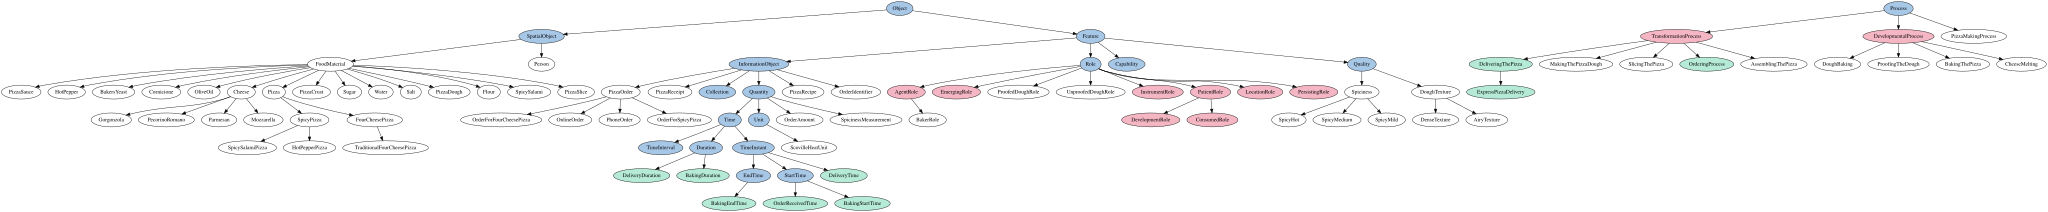

In [162]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-05.owl", format="rdfxml")
print("Saved pizza-05.owl")
display(get_color_tree([sulo, pro, pizza]))

---

### YOUR TURN 1 — `ProofingDuration`

Define a `ProofingDuration` subclass of `sulo:Duration` representing the time the dough is left to ferment. A minimum proofing time of 60 minutes produces better flavour. Define `SlowFermentedDough` as a `PizzaDough` that `hasFeature` some `ProofingDuration` with `hasValue >= 60`. Run the reasoner and verify consistency.

In [163]:
# Exercise 1 — your code here


### YOUR TURN 2 — `PizzaOrderFulfillment`

Define `PizzaOrderFulfillment` as a defined class: a `sulo:Process` that `hasPart` some `OrderingProcess` and `hasPart` some `DeliveringThePizza`. Then create a plain `sulo:Process` individual, attach an `OrderingProcess` individual and a `DeliveringThePizza` individual as parts, run the reasoner, and verify that the individual is automatically classified as `PizzaOrderFulfillment`.

In [164]:
# Exercise 3 — your code here


---

## Summary

In this notebook we added a temporal dimension to the pizza ontology, defining time-instant and duration classes tied to the process pipeline from notebook 03.

### What we built

**Process extensions**

| Class | Type | Role in the pipeline |
|---|---|---|
| `OrderingProcess` | `pro:TransformationProcess` | first step; precedes `MakingThePizzaDough` |
| `DeliveringThePizza` | `pro:TransformationProcess` | last step; follows `SlicingThePizza` |
| `ExpressPizzaDelivery` | `DeliveringThePizza` | delivery with `atTime some (DeliveryDuration & hasValue ≤ 30)` |

**Time instant classes** (all defined via `isTimeOf` restrictions)

| Class | Parent | Marks |
|---|---|---|
| `OrderReceivedTime` | `sulo:StartTime` | start of `OrderingProcess` |
| `BakingStartTime` | `sulo:StartTime` | start of `BakingThePizza` |
| `BakingEndTime` | `sulo:EndTime` | end of `BakingThePizza` |
| `DeliveryTime` | `sulo:TimeInstant` | `DeliveringThePizza` |

**Duration classes** (defined via constrained `hasValue`)

| Class | Constraint | Meaning |
|---|---|---|
| `DeliveryDuration` | — | elapsed delivery time in minutes |
| `BakingDuration` | `8 ≤ hasValue ≤ 15` | normal baking window |

### Key concepts

**`isTimeOf` as a defining restriction.** Using `sulo:isTimeOf.some(ProcessClass)` in an `equivalent_to` axiom ties a time-instant class to the process it marks. Any `StartTime` individual linked to a `BakingThePizza` instance is automatically classified as `BakingStartTime`.

**TBox vs ABox temporal assertions.** `BakingThePizza.is_a.append(atTime.some(BakingStartTime))` is a class-level constraint — it applies to all baking instances. Creating `baking_event_001.atTime = [t_bake_start_001]` is an individual-level assertion for a specific event.

**Classifying processes via `atTime`.** `ExpressPizzaDelivery` is defined as a `DeliveringThePizza` that has `atTime some (DeliveryDuration & hasValue ≤ 30)`. Because the restriction is on the *process* rather than the duration directly, the reasoner can classify a `delivering_001` individual as `ExpressPizzaDelivery` as soon as it is linked to a qualifying duration via `atTime`.

### What comes next

Notebook 06 covers **spatial containment** — representing where pizzas are located using `sulo:contains` and `sulo:isIn`, and how containment interacts with parthood.